# Putting it All Together: A Hands-On WRF Case Study (complete workflow)

This notebook serves as a complete, end-to-end guide for the **Weather Research and Forecasting (WRF)** model. We will move beyond theory to perform a full implementation—covering everything from the initial environment setup and model compilation to the execution of a real-world simulation and the visualization of its results.

### What We Will Accomplish
To master the WRF workflow, we will navigate through three distinct phases:
* **The Build:** Installing the software stack and dependencies using modern HPC tools.
* **The Run:** Processing geographical and meteorological data through the WPS (Preprocessing System) and executing the core model.
* **The Analysis:** Transforming raw NetCDF output into professional-grade meteorological visualizations.

**References & Resources:**
This guide is primarily based on the official [WRF-ARW Online Tutorial](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/) and the [WRF User's Page](https://www2.mmm.ucar.edu/wrf/users/). It has been streamlined specifically for users working within an HPC or interactive notebook environment.


## WRF Execution Workflow

![wrf-execution-workflow](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/images/flow.png)

The WRF modeling system is divided into two primary phases: **Preprocessing (WPS)** and **Model Execution (WRF)**. Each phase relies on a specific configuration file to define parameters like grid resolution, physics schemes, and time steps.

### 1. Preprocessing: The WRF Preprocessing System (WPS)
The WPS prepares terrestrial and meteorological data for the model. It is configured via the `namelist.wps` file and consists of three sequential programs:

* **geogrid.exe**: Defines the simulation's physical domain and interpolates static terrestrial data (such as soil categories, land use, and terrain height) onto the model grid.
* **ungrib.exe**: Reads GRIB-formatted meteorological data (from global models like GFS or ERA5) and converts it into an intermediate binary format.
* **metgrid.exe**: Horizontally interpolates the intermediate meteorological data onto the simulation grid defined by `geogrid`. The resulting files are the direct inputs for the WRF model.

### 2. Model Execution: WRF
Once the grid is prepared, the simulation is performed in two stages, both controlled by the `namelist.input` file:

* **real.exe**: Consumes the output from `metgrid` to perform vertical interpolation and ensure the data is dynamically consistent. It generates the initial conditions (`wrfinput`) and lateral boundary conditions (`wrfbdy`).
* **wrf.exe**: The core solver that performs the actual numerical integration of the atmospheric equations. This step produces the final simulation output files (NetCDF format) used for analysis.

> **Note:** You can find documented examples of the `namelist.wps` and `namelist.input` files used in this case study in the [input/](./complete/input) directory.

---


## Case Study: Hurricane Matthew

In this module, we will execute a complete WRF simulation from start to finish—covering the entire pipeline from data preprocessing to model execution.

![Hurricane Matthew Satellite](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/CASES/SingleDomain/matthew.jpg)

### Simulation Overview
We are utilizing the [Hurricane Matthew](https://www.nhc.noaa.gov/data/tcr/AL142016_Matthew.pdf) test case provided by the [WRF-ARW Online Tutorial](https://www2.mmm.ucar.edu/wrf/OnLineTutorial/CASES/SingleDomain/index.php). This scenario simulates the intensification and trajectory of one of the most powerful and destructive tropical cyclones of the 2016 Atlantic hurricane season.

### Model Configuration

To keep the computational requirements manageable for this guide while still capturing the storm's core dynamics, we will use the following configuration:

* **Simulation Window:** A 6-hour window from **00:00 UTC to 06:00 UTC on October 6, 2016**.
* **Domain Setup:** A single nested domain (d01).
* **Horizontal Resolution:** 27 km.
* **Objective:** To observe the development and evolution of the hurricane's pressure system and wind fields.

By running this "small" version of the simulation, you will gain hands-on experience with the file handoffs between WPS and WRF without the long wait times associated with high-resolution production runs. 

---

## Step 1. Environment Setup

We will begin by installing the WRF software stack and configuring a Python virtual environment for data visualization.

### 1.1 WRF Installation

Traditionally, installing WRF is a rigorous process that requires manual source code management, environment variable configuration, and the complex compilation of libraries such as **NetCDF**, **HDF5**, and **MPI**. For those unfamiliar with build systems, this can be both time-consuming and error-prone.

To streamline this, we will use [Spack](https://spack.readthedocs.io/en/latest/), a flexible package manager specifically designed for High-Performance Computing (HPC). Spack simplifies the installation of scientific software by:

* **Automated Dependency Management:** It automatically fetches and compiles all required libraries and sub-dependencies.
* **Architecture Optimization:** Since Spack compiles from source, it optimizes the binaries for your specific CPU architecture, ensuring maximum performance.
* **Version Control:** It handles multiple versions and configurations of the same software without conflicts.

> **HPC Tip:** In professional clusters, software is rarely installed "globally." Spack allows us to create reproducible software environments that are tailored to the hardware we are using.

### 1.2 Loading the Software Stack

On our current cluster, **Spack** and the **WRF/WPS** modules are already pre-installed. You can bypass the compilation process and load the necessary software into your current session by running:

```bash
module load spack
module load wrf
module load wps
```

**Manual Installation (Optional)**

If you wish to replicate this setup on your own machine or a different cluster, you would first need to install [Spack](https://spack.readthedocs.io/en/latest/getting_started.html). Once Spack is configured, you can use the following commands to build the suite from source:


```bash
# Clone the Spack repository (minimal depth for speed)
git clone --depth=2 [https://github.com/spack/spack.git](https://github.com/spack/spack.git)

# Initialize the Spack environment
source spack/share/spack/setup-env.sh

# Install WRF and WPS 
# Note: Compilation can take 30-60 minutes depending on your hardware.
spack install wrf@4.5.2
spack install wps@4.5

# Load the newly installed packages into your path
spack load wrf
spack load wps
```

**Performance Note:** When installing locally, Spack will detect your CPU architecture and apply specific compiler optimizations (e.g., AVX-512) to ensure `wrf.exe` runs as efficiently as possible on your hardware.


### 1.3 Python Environment & Visualization Setup

To handle data analysis and visualization directly within this notebook, we need to configure a dedicated Python virtual environment. This ensures our dependencies remain isolated and do not conflict with system-level packages.

```bash
# Create a virtual environment (recommended)
python -m venv wrf-venv
source wrf-venv/bin/activate

# Install dependencies
pip install -r requirements.txt
```

**Installing `wrf-python` from source**

An additional requirement for this tutorial is the `wrf-python` package. Although it is available on PyPI, the PyPI version is currently outdated and may not be compatible with recent Python releases. For this reason, we will install the latest stable version directly from the official GitHub source:

```bash
# Download and install wrf-python from source
wget https://codeload.github.com/NCAR/wrf-python/tar.gz/refs/tags/v1.4.2
tar -xvf v1.4.2
cd wrf-python-1.4.2
pip install .
```

**Important:** After the installation finishes, you must change the **Selected Kernel** of this notebook to `wrf-venv`. This allows the notebook to "see" the packages you just installed.


## Step 2. Downloading WRF Input Data

Before we can begin preprocessing, we must acquire the static terrestrial data and the dynamic meteorological fields. For this case study, we will download three primary archives:

* **`matthew_1deg.tar.gz`**: Meteorological initial and boundary conditions from the Global Forecast System (GFS) at 1° resolution, required for the `ungrib` process.
* **`matthew_sst.tar.gz`**: Supplemental Sea Surface Temperature (SST) data. Accurate SSTs are vital for hurricane simulations to correctly model heat flux from the ocean.

Execute the following commands to create a local `data` directory and retrieve the datasets:


In [17]:
%%script bash
#!/bin/bash

# Create a directory for the input data
mkdir -p data
cd data

# Download GFS data for Hurricane Matthew
if [ ! -f matthew_1deg.tar.gz ]; then
    wget 'https://drive.usercontent.google.com/download?export=download&id=1ho_DhS0P4XYosNObqY3EZR-DuUTJIIFn&confirm=t' -O matthew_1deg.tar.gz
fi

# Download SST data for Hurricane Matthew
if [ ! -f matthew_sst.tar.gz ]; then
    wget 'https://drive.usercontent.google.com/download?export=download&id=1NZHXmOquFvOwupnpbFvAFZ0uJv-kADZT&confirm=t' -O matthew_sst.tar.gz
fi


### **WPS Geographic Data (WPS_GEOG)**

The `geogrid` program requires high-resolution terrestrial data to define your simulation domain. This dataset includes critical surface parameters such as **topography** (terrain height), **land-use categories**, and **soil properties**. You can download using the following command:

```bash
wget https://www2.mmm.ucar.edu/wrf/src/wps_files/geog_high_res_mandatory.tar.gz
```

#### **Data Management & Best Practices**
* **Standard Installation:** Typically, this data is downloaded as a compressed archive (`geog_high_res_mandatory.tar.gz`) and extracted to your storage. 
* **Path Depth Warning:** Avoid placing the dataset within a deeply nested directory structure. Long or overly complex file paths can occasionally cause the WPS programs to crash due to internal character limits. 
* **Production Environments:** To save disk space and avoid redundant downloads, production clusters usually provide a shared, uncompressed version of this data. In this tutorial, the dataset is globally accessible at: `/shared/WPS_GEOG`.


> **Note for Local Users:** If you are running this notebook on your own machine rather than our provided HPC environment, you must update the `geog_data_path` variable in your `namelist.wps` to point to your local data directory.

## Step 3: WPS and WRF Configuration

Before we execute the models, we must provide the necessary configuration and lookup tables. These files define the physics, dynamics, and data formats used during the simulation. 

We have provided a pre-configured set of files in the `input/` directory:

```text
input
├── GEOGRID.TBL    # Table defining terrestrial data parameters
├── METGRID.TBL    # Table defining interpolation methods for met-data
├── namelist.input # Main configuration file for real.exe and wrf.exe
├── namelist.wps   # Main configuration file for WPS (geogrid, ungrib, metgrid)
├── Vtable.GFS     # Variable table for GFS meteorological data
└── Vtable.SST     # Variable table for Sea Surface Temperature data

```

**Note:** The `namelist.wps` and `namelist.input` files have been pre-tuned for the Hurricane Matthew 27 km case study. They are set to read the data downloaded in Step 2 and are ready for execution without further modification.

## Step 4: Running WPS and WRF

We are now ready to enter the execution phase. The workflow follows a strict sequence: we will run the WPS components (**geogrid**, **ungrib**, and **metgrid**) to prepare our data, followed by the core **WRF** model.

As discussed in our previous guide, heavy computational tasks in HPC environments should not be run interactively on login nodes. Instead, we submit them as batch jobs to the cluster's compute nodes. This ensures we have dedicated resources (CPU and Memory) for our simulation. The job scripts required for each step are pre-configured and located in the `scripts/` directory.

**Using `slurm-magic`**

To keep our workflow within this notebook, we will use the **`slurm-magic`** extension. This tool allows us to use the `%%sbatch` cell magic to submit jobs directly to the Slurm queue without switching to a terminal window.

First, let's load the extension into the notebook:

In [18]:
%load_ext slurm_magic

The slurm_magic extension is already loaded. To reload it, use:
  %reload_ext slurm_magic


For each of the following steps, we will:
- Submit the job using the `%%sbatch` command.
- Verify the output before moving to the next component in the pipeline.

### 4.1 WPS: Geogrid

The first stage of the WPS pipeline is **Geogrid**. Its primary role is to define the physical simulation domain and interpolate static terrestrial data (such as topography, land-use categories, and soil properties) onto the model grid.

**Data & Directory Preparation**

Before executing the program, we must ensure the high-resolution geographic data is uncompressed. We will use a dedicated directory, `pre/` (referenced as `$WRF_PRE`), to store the intermediate outputs from both `geogrid` and `ungrib`. These files serve as the essential precursors for the final `metgrid` interpolation.

In the following cell, we will:
- Dynamically update the `namelist.wps` to point to the correct absolute data paths.
- Generate the `geo_em.d01.nc` file, which contains the processed terrestrial map for our Hurricane Matthew domain.

In [19]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wps-geogrid
#SBATCH --ntasks=1
#SBATCH --output=wps_geogrid.out
#SBATCH --error=wps_geogrid.err

# Set ENV variables
CUR_DIR=$(pwd)
DATA_DIR=${CUR_DIR}/data                
WRF_INP=${CUR_DIR}/input 
WRF_PRE=${CUR_DIR}/pre
mkdir -p $WRF_PRE

# Load modules
module load spack 
module load wps

cd $WRF_PRE
# Create symbolic links for geogrid input files
ln -sf $WRF_INP/GEOGRID.TBL .
ln -sf $WRF_INP/namelist.wps .

# Run
geogrid.exe

'Submitted batch job 84\n'

Once submited, you can check it using `squeue`.

In [20]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,84,split,wps-geog,roosevel,R,0:02,1,servbsbhpc005


If the queue is empty, your job has concluded. At this point, you should inspect the `wps_geogrid.out` log file to verify that the process finished without errors.

**Verification:** Search for the following banner at the end of the log file. Seeing this output confirms a successful run, and you may proceed to the next step:

```txt
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!  Successful completion of geogrid.        !
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
```

In [21]:
%%script bash
tail wps_geogrid.out

    OA4SS (priority=1, resolution='default', path='/shared/WPS_GEOG/orogwd3_10m/oa4ss/')
    OL1SS (priority=1, resolution='default', path='/shared/WPS_GEOG/orogwd3_10m/ol1ss/')
    OL2SS (priority=1, resolution='default', path='/shared/WPS_GEOG/orogwd3_10m/ol2ss/')
    OL3SS (priority=1, resolution='default', path='/shared/WPS_GEOG/orogwd3_10m/ol3ss/')
    OL4SS (priority=1, resolution='default', path='/shared/WPS_GEOG/orogwd3_10m/ol4ss/')
    BATHYMETRY (priority=1, resolution='default', path='/shared/WPS_GEOG/topobath_30s/')

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!  Successful completion of geogrid.        !
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


**Pro-Tip:** If the job finishes but you don't see this message, check `wps_geogrid.err` for specific error codes related to missing data paths or incorrectly linked tables.


### 4.2 WPS: Ungrib

Now that the terrestrial grid is established, we must process the "dynamic" meteorological data. The **Ungrib** component extracts fields from GRIB-formatted files and converts them into a simplified intermediate format that the WRF system can ingest.

Because we are simulating a hurricane, we require two distinct data streams: **atmospheric fields** (temperature, wind, pressure) from the GFS and **Sea Surface Temperature (SST)** fields.

**Key Actions in this Step:**

- **Dual-Pass Extraction:** We run `ungrib.exe` twice (once for the GFS data and once for the SST data) to ensure both sets of variables are available for the simulation.
- **Vtable Mapping:** We link the specific `Vtable` for each data source (GFS vs. SST), which acts as a translation key to help the model identify the correct meteorological variables.
- **Prefix Management:** We use the `sed` command to dynamically update the prefix in `namelist.wps`. This ensures the first pass creates files named `FILE:YYYY...` for GFS data and the second pass creates `SST:YYYY....` for SST data.
- **Staging:** After each pass, the script loops through the generated intermediate files and creates symbolic links in the `$WRF_PRE` directory, making them accessible for the final preprocessing stage.

In [22]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wps-ungrid
#SBATCH --ntasks=1
#SBATCH --output=wps_ungrid.out
#SBATCH --error=wps_ungrid.err

# Set ENV variables
CUR_DIR=$(pwd)
DATA_DIR=${CUR_DIR}/data                
WRF_INP=${CUR_DIR}/input 
WRF_PRE=${CUR_DIR}/pre

# Load software modules
module load spack 
module load wps

## GFS data
# Uncompress matthew GFS data if not already done
if [ ! -d "$DATA_DIR/matthew" ]; then
    tar -xvf $DATA_DIR/matthew_1deg.tar.gz -C $DATA_DIR
fi

# Move to matthew directory
cd $DATA_DIR/matthew

# Link Vtable and namelist.wps from input directory
ln -sf $WRF_INP/Vtable.GFS Vtable
link_grib.csh ./fnl
ln -sf $WRF_INP/namelist.wps .

# Correct file prefix
sed -i "s/^.*prefix.*$/    prefix = 'FILE',/" namelist.wps

# Run
ungrib.exe

# Create symbolic links for ungrib output files FILE:2016-10-06_00 FILE:2016-10-06_06 ...
for f in FILE:*; do
  ln -sf "$PWD/$f" $WRF_PRE
done

## SST data
# Uncompress matthew SST data if not already done
if [ ! -d "$DATA_DIR/matthew_sst" ]; then
    tar -xvf $DATA_DIR/matthew_sst.tar.gz -C $DATA_DIR
fi

# Move to matthew_sst directory
cd $DATA_DIR/matthew_sst

# Link Vtable and namelist.wps from input directory
ln -sf $WRF_INP/Vtable.SST Vtable
link_grib.csh ./rtg_sst_grb
ln -sf $WRF_INP/namelist.wps .

# Correct file prefix
sed -i "s/^.*prefix.*$/    prefix = 'SST',/" namelist.wps

# Run
ungrib.exe

# Create symbolic links for ungrib output files SST:2016-10-06_00 SST:2016-10-06_06 ...
for f in SST:*; do
  ln -sf "$PWD/$f" $WRF_PRE
done

'Submitted batch job 85\n'

In [23]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,85,split,wps-ungr,roosevel,R,0:03,1,servbsbhpc005


**Verification:** Once the Slurm queue clears, check the `wps_ungrid.out` log. You should see "Successful completion" messages for both the GFS and SST passes. Additionally, verify that your `pre/` directory contains both `FILE:` and `SST:` prefixed files for the entire 6-hour simulation window.

### 4.3 WPS: Metgrid

**Metgrid** is the final "merger" of the WPS suite. It horizontally interpolates the meteorological fields (the `FILE` and `SST` outputs from **Ungrib**) onto the simulation domain created by **Geogrid** (`geo_em`). By the end of this step, the atmospheric data is perfectly aligned with your custom geographic grid.

**Key Actions in this Step:**

- **Workspace Consolidation:** The script moves into the `$WRF_PRE` directory, which now contains all necessary precursors: the terrestrial map (`geo_em`), the atmospheric files (`FILE:`), and the sea surface temperature files (`SST:`).
- **Environment Linking:** We link the `METGRID.TBL` and `namelist.wps` from the `input` directory to define the interpolation methods (e.g., bilinear vs. nearest-neighbor) used for different meteorological variables.
- **Horizontal Interpolation:** Running `metgrid.exe` maps the coarse GFS data onto your high-resolution simulation grid.
- **WRF-Ready Output:** This step generates `met_em.d01.YYYY-MM-DD_HH:00:00.nc` files. These netCDF files contain the complete initial and boundary conditions required to start the WRF model.

In [24]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wps-metgrid
#SBATCH --ntasks=1
#SBATCH --mem-per-cpu=1G
#SBATCH --output=wps_metgrid.out
#SBATCH --error=wps_metgrid.err

# Set ENV variables
CUR_DIR=$(pwd)
DATA_DIR=${CUR_DIR}/data                
WRF_INP=${CUR_DIR}/input 
WRF_PRE=${CUR_DIR}/pre

# Load modules
module load spack 
module load wps

# Move to WPS_PRE directory
cd $WRF_PRE

# Link control files for metgrid
ln -sf $WRF_INP/METGRID.TBL .
ln -sf $WRF_INP/namelist.wps .

# Run
metgrid.exe

'Submitted batch job 86\n'

In [25]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,86,split,wps-metg,roosevel,R,0:02,1,servbsbhpc005


Monitor your job status with `squeue`. Once finished, inspect` wps_metgrid.out`. If you see the message `"Successful completion of metgrid"`, you have successfully finished the WPS preprocessing phase!

### 4.4 WRF: initialization program (real.exe)

Before the actual simulation begins, we must run `real.exe`. While Metgrid handled the horizontal interpolation, `real.exe` performs the vertical interpolation (mapping the meteorological data from the GFS pressure levels onto the specific vertical "sigma levels" defined in your `namelist.input`).

**Key Actions in this Step:**

- **Vertical Coordinate Mapping:** It translates the 3D atmospheric data into the model's specific vertical grid, accounting for the complex terrain (topography) defined in Geogrid.
- **Consistency Checks:** The program verifies that the input data, the namelist settings, and the grid dimensions are all physically consistent.
- **Boundary Condition Generation:** It creates two vital files: 
    - `wrfinput_d01`: The "snapshot" of the atmosphere at the exact start time ($T=0$).
    - `wrfbdy_d01`: The "boundary" data that tells the model what is happening at the edges of the domain throughout the simulation.

In [26]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wrf-real
#SBATCH --ntasks=1
#SBATCH --output=wrf_real.out
#SBATCH --error=wrf_real.err

# Set ENV variables
CUR_DIR=$(pwd)            
WRF_INP=${CUR_DIR}/input 
WRF_PRE=${CUR_DIR}/pre
WRF_REAL=${CUR_DIR}/real
mkdir -p $WRF_REAL

# Load modules
module load spack 
module load wrf

# Move to WRF_REAL directory
cd $WRF_REAL

# Link control files for real.exe
ln -sf $WRF_INP/* .
ln -sf $WRF_PRE/* .

# Run
real.exe

'Submitted batch job 87\n'

Monitor the job via `squeue`.

In [27]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,87,split,wrf-real,roosevel,R,0:01,1,servbsbhpc005


Once finished, check the end of the `rundir/rsl.out.0000` log file. Look for the message `SUCCESS COMPLETE REAL_EM`. 

If you see `wrfinput_d01` and `wrfbdy_d01` in your `real/` folder, you are officially ready to run the hurricane simulation!

### 4.5 WRF: model execution (wrf.exe)

This is the core of the workflow: the actual atmospheric simulation. Here, the WRF model integrates the equations of fluid dynamics and thermodynamics over time, using the physics schemes (microphysics, convection, radiation) defined in your `namelist.input`.

**Computational Performance**

WRF simulations are computationally intensive. The runtime depends on your grid resolution, the size of your domain, and the complexity of the physics. For our test case, the full 2-day forecast for Hurricane Matthew would typically take about 50 minutes on 4 processors. 

To keep this tutorial efficient, we have scaled the run down to the first **6 hours** of the forecast, which should complete in approximately **4 minutes**. 

While you can increase the number of processors via `#SBATCH --ntasks=<number>`, remember that "more" isn't always "faster." At a certain point, the time spent on communication between processors (overhead) outweighs the speed gained from parallelization.

**Key Actions in this Step:**

- **Environment Preparation:** We create a fresh `rundir/` to avoid conflicts with previous trial runs.
- **Resource Linking:** We link the necessary physics tables from the WRF installation directory (`WRF_HOME`), our pre-configured namelists, and the initialization files (`wrfinput` and `wrfbdy`) generated in the previous step.
- **Numerical Integration:** We execute `wrf.exe` using `srun`. This begins the "marching" of time steps to simulate the hurricane's evolution.

In [28]:
%%sbatch
#!/bin/bash
#SBATCH --job-name=wrf-simulation
#SBATCH --ntasks=4
#SBATCH --mem-per-cpu=1G
#SBATCH --output=wrf_simulation.out
#SBATCH --error=wrf_simulation.err

# Set ENV variables
CUR_DIR=$(pwd)            
WRF_RUN=${CUR_DIR}/rundir
WRF_INP=${CUR_DIR}/input
WRF_REAL=${CUR_DIR}/real
SRUN_FLAGS="-n $SLURM_NTASKS"

# Clear previous outputs and create new one
rm -rf $WRF_RUN && mkdir -p $WRF_RUN

# Load modules
module load spack 
module load wrf

# Move to WRF_RUN directory and link control files for wrf.exe
cd ${WRF_RUN}
ln -sfn ${WRF_HOME}/run/* .	
cp ${WRF_HOME}/configure.wrf .
ln -sfn ${WRF_INP}/* .
ln -sfn ${WRF_REAL}/* .

# Run 6-hour forecast
srun $SRUN_FLAGS ./wrf.exe

'Submitted batch job 88\n'

Wait until the job finish, you can check it using `squeue`.

In [29]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,88,split,wrf-simu,roosevel,R,0:01,1,servbsbhpc005


**Checking the Logs**

While the job is running (or after it finishes), you can verify the model's progress in real-time by checking the WRF output log:

In [31]:
%%script bash
tail rundir/rsl.out.0000

TimingTiming for main: time 2016-10-06_05:47:30 on domain   1:    2.96362 elapsed seTiming for main: time 2016-10-06_05:47:30 on domain   1:    3.00762 elapsed seconds
Timing for main: time 2016-10-06_05:50:00 on domain   1:    0.60469 elapsed seconds
Timing for main: time 2016-10-06_05:52:30 on domain   1:    0.60545 elapsed seconds
Timing for main: time 2016-10-06_05:55:00 on domain   1:    0.60582 elapsed seconds
Timing for main: time 2016-10-06_05:57:30 on domain   1:    0.59985 elapsed seconds
Timing for main: time 2016-10-06_06:00:00 on domain   1:    0.57155 elapsed seconds
Timing for Writing wrfout_d01_2016-10-06_06:00:00 for domain        1:    0.31377 elapsed seconds
d01 2016-10-06_06:00:00 wrf: SUCCESS COMPLETE WRF
    0.31159 elapsed seconds
d01 2016-10-06_06:00:00 wrf: SUCCESS COMPLETE WRF


If you see the message **`SUCCESS COMPLETE WRF`** at the end of your log file, it means your simulation has ended successfully, and you are ready to move to the next step.

### The "All-in-One" WRF Workflow (Optional)

In the previous sections, we executed each component manually to understand the pipeline. However, in a production environment, you rarely want to sit and wait for one job to finish before submitting the next. Instead, we use **Job Dependencies**.

By using the `--dependency` flag in Slurm, we can submit the entire pipeline at once. The scheduler will hold the dependent jobs in the queue (status `PD`) and only trigger them once their "parent" job completes successfully.

**Why this is efficient?:**

- **Automation:** You can submit your work and walk away; the cluster handles the hand-offs.
- **Parallelism:** Steps that don't depend on each other (like `geogrid` and `ungrib`) can run simultaneously if the cluster has available resources.
- **Safety:** If `ungrib` fails due to a data error, Slurm will automatically cancel `metgrid`, `real`, and `wrf`, saving you from wasting computational hours on a doomed simulation.

In [32]:
%%script bash
#!/bin/bash

## Clear previous outputs
rm -rf pre
rm -rf real
rm -rf rundir

## WPS jobs
# ungrid, and geogrid can run in parallel, but metgrid needs to wait for both to finish
jid_ungrid=$(sbatch --parsable scripts/wps-ungrid.slurm)
jid_geogrid=$(sbatch --parsable scripts/wps-geogrid.slurm)
jid_metgrid=$(sbatch --parsable --dependency=afterany:$jid_ungrid:$jid_geogrid scripts/wps-metgrid.slurm)

## WRF jobs
jid_real=$(sbatch --parsable --dependency=afterany:$jid_metgrid scripts/wrf-real.slurm)
sbatch --dependency=afterany:$jid_real scripts/wrf-sim.slurm


Submitted batch job 93


**HPC Tip:** Note the use of `afterok` instead of `afterany`. Using `afterok` ensures the next job only runs if the previous one finished successfully (with a zero exit code). If a step crashes, the rest of the chain is halted.

As was done before, you can check your jobs progress with `squeue`.

In [33]:
%squeue --me

,JOBID,PARTITION,NAME,USER,ST,TIME,NODES,NODELIST(REASON)
0,91,split,wps-metg,roosevel,PD,0:00,1,(Dependency)
1,92,split,wrf-real,roosevel,PD,0:00,1,(Dependency)
2,93,split,wrf-simu,roosevel,PD,0:00,1,(Dependency)
3,89,split,wps-ungr,roosevel,R,0:02,1,servbsbhpc005
4,90,split,wps-geog,roosevel,R,0:02,1,servbsbhpc005


## Step 5: WRF Visualization

The raw output files from WRF (known as `wrfout*` files) are stored in NetCDF format. While powerful, these files contain variables on a staggered "C-grid" that are not immediately ready for plotting.

To transform this raw data into meaningful maps, we use the `wrf-python` library. This package acts as a specialized bridge, handling the diagnostic calculations (like converting pressure and temperature into Sea Level Pressure) and the map projections (integrating with `Cartopy`) needed for accurate geographic representation.

### 5.1 Single Time Step Visualization

To verify our simulation, we will start by plotting a single snapshot. We will focus on **Sea Level Pressure (SLP)**. In hurricane modeling, SLP is the primary indicator of storm intensity and position; the tighter the contours and the lower the central pressure, the stronger the hurricane.


**The `plot_slp` Function**

The following function automates several complex tasks:
- **Diagnostic Extraction:** Uses `getvar` to calculate SLP from the raw pressure and geopotential height fields.
- **Smoothing:** Applies a 2D Gaussian-like smoother (`smooth2d`) to remove numerical noise and highlight the large-scale pressure patterns.
- **Coordinate Mapping:** Automatically handles the Lambert Conformal or Mercator projections used by WRF so the coastlines line up perfectly.

/home/roosevelt.chavez.cw/INF0090-HPC-AI/module1_intro_hpc/05-final-example/complete-case/wrf-venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


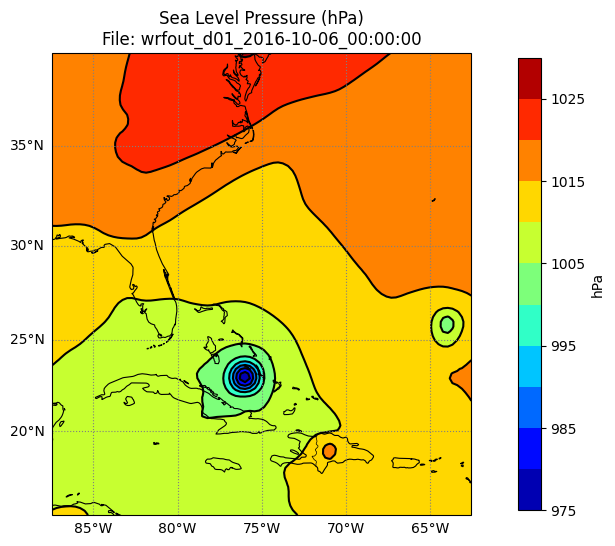

In [37]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature

from wrf import (
    getvar, smooth2d, latlon_coords, get_cartopy,
    to_np, cartopy_xlim, cartopy_ylim
)

def plot_slp(output_file, base_dir="", smooth_passes=3, cenweight=4, cmap="jet"):
    """
    Plots Sea Level Pressure from a WRF output file with geographic features.
    """
    # Open the NetCDF file
    ncfile = Dataset(base_dir + output_file)

    try:
        # 1. Extract and Smooth SLP
        slp = getvar(ncfile, "slp")
        smooth_slp = smooth2d(slp, smooth_passes, cenweight=cenweight)
        
        # 2. Get the latitude and longitude coordinates
        lats, lons = latlon_coords(slp)

        # 3. Get the native map projection from the WRF file
        cart_proj = get_cartopy(smooth_slp)

        # 4. Initialize the plot
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=cart_proj)

        # 5. Add Geographic Features
        states = NaturalEarthFeature(
            category="cultural",
            scale="50m",
            facecolor="none",
            name="admin_0_boundary_lines_land"
        )
        ax.add_feature(states, linewidth=0.5, edgecolor="black")
        ax.coastlines("50m", linewidth=0.8)

        # 6. Plot Contours (Lines and Filled)
        plt.contour(
            to_np(lons), to_np(lats), to_np(smooth_slp),
            10, colors="black", transform=crs.PlateCarree()
        )

        contourf = plt.contourf(
            to_np(lons), to_np(lats), to_np(smooth_slp),
            10, transform=crs.PlateCarree(),
            cmap=plt.get_cmap(cmap)
        )

        # 7. Final Polish (Colorbar, Labels, Gridlines)
        plt.colorbar(contourf, ax=ax, shrink=0.98, label="hPa")
        ax.set_xlim(cartopy_xlim(smooth_slp))
        ax.set_ylim(cartopy_ylim(smooth_slp))

        gl = ax.gridlines(draw_labels=True, color="gray", linestyle="dotted")
        gl.right_labels = False
        gl.top_labels = False

        plt.title(f"Sea Level Pressure (hPa)\nFile: {output_file}")
        plt.show()

    finally:
        ncfile.close()

# Execute the plot for the third hour of the simulation
plot_slp("wrfout_d01_2016-10-06_00:00:00", "rundir/")

### 5.2 Time Step Animation

A single snapshot is useful for verification, but weather is inherently dynamic. To truly understand the movement of Hurricane Matthew, we can string our output files together into an animation. This allows us to track the storm's track and identify whether it is intensifying (deepening pressure) or weakening.


**The Challenge of Dynamic Scales**

When animating meteorological data, we face a specific challenge: **the range of the data changes**. If we let Python auto-scale the colors for every frame, the colors would "flicker" as the hurricane's central pressure drops.

**Our `animate_slp` function solves this by:**

- **Preprocessing the Range:** It scans all files first to find the absolute minimum and maximum pressure (`vmin` and `vmax`) across the entire simulation.
- **Fixed Colorbar:** By fixing the scale, a specific shade of blue will always represent the same pressure value, making the animation physically meaningful.
- **Error Handling:** It intelligently skips missing files (like a forecast step that hasn't finished yet) so the script doesn't crash.

Skipping rundir/wrfout_d01_2016-10-06_03:00:00: [Errno -101] NetCDF: HDF error: 'rundir/wrfout_d01_2016-10-06_03:00:00'


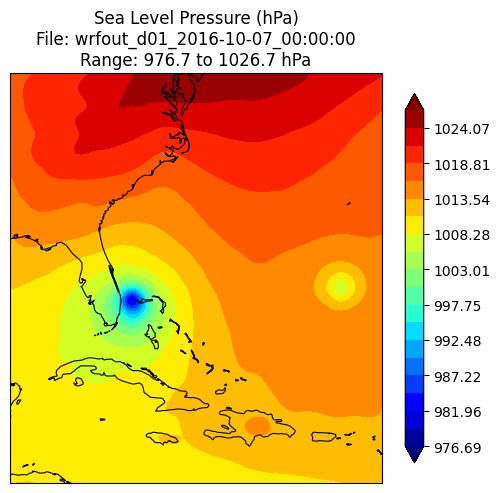

In [38]:
from matplotlib.animation import FuncAnimation
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt

def animate_slp(output_files, base_dir="", output_filename="slp.gif", smooth_passes=3, cenweight=4, cmap="jet", interval=500):
    
    valid_files = [] # Track which files actually work
    
    def get_color_scale(files, base_dir=""):
        vmin, vmax = float("inf"), float("-inf")
        found_files = []
        for f in files:
            path = base_dir + f
            try:
                ncfile = Dataset(path)
                try:
                    slp = getvar(ncfile, "slp")
                    smooth_slp = smooth2d(slp, smooth_passes, cenweight=cenweight)
                    vmin = min(vmin, float(smooth_slp.min()))
                    vmax = max(vmax, float(smooth_slp.max()))
                    found_files.append(f) # Only add if reading succeeded
                finally:
                    ncfile.close()
            except OSError as e:
                print(f"Skipping {f}: {e}")
                continue 
        return vmin, vmax, found_files

    # 1. Identify valid files and set the global scale
    vmin, vmax, valid_files = get_color_scale(output_files, base_dir)
    
    if not valid_files:
        print("No valid files found to animate.")
        return

    clevels = np.linspace(vmin, vmax, 20)
    fig = plt.figure(figsize=(6, 6))

    def update(frame):
        fig.clear()
        # Use the valid_files list instead of the original output_files
        current_file = valid_files[frame]
        
        try:
            ncfile = Dataset(base_dir + current_file)
            try:
                slp = getvar(ncfile, "slp")
                smooth_slp = smooth2d(slp, smooth_passes, cenweight=cenweight)
                lats, lons = latlon_coords(slp)
                cart_proj = get_cartopy(slp)
                
                ax = plt.axes(projection=cart_proj)
                ax.coastlines("50m", linewidth=0.8)
                
                contourf = ax.contourf(
                    to_np(lons), to_np(lats), to_np(smooth_slp),
                    levels=clevels,
                    vmin=vmin,
                    vmax=vmax,
                    transform=crs.PlateCarree(),
                    cmap=plt.get_cmap(cmap),
                    extend="both"
                )

                plt.colorbar(contourf, ax=ax, shrink=0.8, pad=0.05, ticks=clevels[::2])
                fn = current_file.split('/')[-1]
                plt.title(f"Sea Level Pressure (hPa)\nFile: {fn}\nRange: {vmin:.1f} to {vmax:.1f} hPa")
            finally:
                ncfile.close()
        except Exception as e:
            print(f"Error during animation update on {current_file}: {e}")

    # Use len(valid_files) so the animation doesn't try to index missing data
    anim = FuncAnimation(fig, update, frames=len(valid_files), repeat=False, interval=interval)
    anim.save(output_filename, writer="pillow")

# List remains the same
output_files = [
    # Our 6-hour forecast
    "rundir/wrfout_d01_2016-10-06_00:00:00",
    "rundir/wrfout_d01_2016-10-06_03:00:00",
    "rundir/wrfout_d01_2016-10-06_06:00:00",
    # Previously run 18-hour forecast
    "output/wrfout_d01_2016-10-06_09:00:00",
    "output/wrfout_d01_2016-10-06_12:00:00",
    "output/wrfout_d01_2016-10-06_15:00:00",
    "output/wrfout_d01_2016-10-06_18:00:00",
    "output/wrfout_d01_2016-10-06_21:00:00",
    "output/wrfout_d01_2016-10-07_00:00:00",
]

animate_slp(output_files, output_filename="hurricane_matthew.gif", interval=500)

![hurricane_matthew.gif](hurricane_matthew.gif)

While this animation offers a compelling look at the storm's track, it represents just a fraction of the insights hidden within your simulation data. To truly understand the dynamics of a hurricane, you can leverage the full power of the `wrf-python` library to calculate and visualize advanced diagnostics like **Potential Vorticity**, **Simulated Radar Reflectivity**, and **Vertical Cross-sections**.

By mastering these tools, you can transition from simply running a model to performing deep meteorological analysis. To explore advanced techniques—such as multi-panel plotting, wind vector overlays, or 3D data extraction—be sure to visit the official resources:

* **[wrf-python Documentation](https://wrf-python.readthedocs.io/)**: For detailed API references and function logic.
* **[wrf-python Gallery & Examples](https://wrf-python.readthedocs.io/en/latest/plot.html)**: For ready-to-use scripts covering a wide range of weather variables.

---

**Congratulations!**

You have successfully navigated the entire WRF pipeline:

1. **Setup:** Configured the environment and downloaded data.
2. **Preprocessing:** Used WPS to map geography and weather data.
3. **Simulation:** Executed the WRF model on an HPC cluster using Slurm.
4. **Analysis:** Transformed raw binary data into a professional scientific animation.



With your animation complete, you have successfully crossed the finish line of this first module. 

This tutorial serves as a foundational milestone in your journey through **High-Performance Computing**, demonstrating that HPC is not just about raw power, but about the structured orchestration of data, software, and hardware to solve complex, real-world problems.

By simulating Hurricane Matthew, you have moved beyond theoretical exercises to mastering the same tools and workflows used by professional climate scientists and weather agencies worldwide. You are now equipped with the fundamental skills (from job scheduling and environment management to parallel execution) needed to tackle even larger computational challenges in the modules to come.